# Clinical Trials Intelligence Explorer — Exploratory Data AnalysisExploring 5,928 clinical trials with at least one German site, across seven therapeutic areas(COPD, asthma, pulmonary fibrosis, non-small cell lung cancer, type 2 diabetes, cardiovasculardisease, rheumatoid arthritis), pulled from the ClinicalTrials.gov public API v2.This notebook works from the cleaned, normalized SQLite database built in `sql/build_db.py`.

In [1]:
import sqlite3import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snssns.set_style('whitegrid')plt.rcParams['figure.dpi'] = 100conn = sqlite3.connect('../data/trials.db')trials = pd.read_sql("SELECT * FROM trials", conn)phases = pd.read_sql("SELECT * FROM trial_phases", conn)conditions = pd.read_sql("SELECT * FROM trial_conditions", conn)conn.close()print(f"Loaded {len(trials)} trials")

Loaded 5928 trials

## 1. Enrollment: interventional vs. observational trialsBefore looking at enrollment size at all, it's worth checking whether it's even meaningful toaverage across the dataset as a whole. Observational studies (registries, cohort studies) canlegitimately enroll hundreds of thousands of patients — that's not a data error, it's a differentkind of study design than an interventional trial. Mixing the two would badly distort any single"average enrollment" statistic, so they're kept separate here.

In [2]:
top_enrollment = trials.nlargest(5, 'enrollment_count')[['title', 'enrollment_count', 'study_type']]print(top_enrollment.to_string(index=False))

                                                        title  enrollment_count    study_type                   The Global Cardiovascular Risk Consortium         3000000.0 OBSERVATIONALStudy of Rivaroxaban Use and Potential Adverse Outcomes...          665533.0 OBSERVATIONALTo Assess the Risk of Acute Pancreatitis in Patients...             494679.0 OBSERVATIONALA Study to Observe the Effectiveness of Empagliflozin...            327624.0 OBSERVATIONAL      The Oxford Risk Factors And Non-Invasive Imaging Study        250000.0 OBSERVATIONAL

All five of the largest studies are observational registries, not interventional trials —confirms this is a structural pattern in the data, not noise. Notably, the Empagliflozin study(NCT03817463) is a Boehringer Ingelheim product.

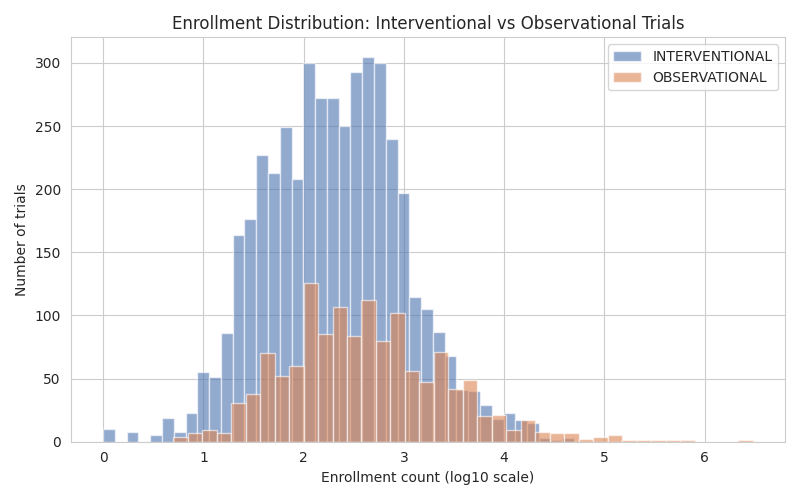

In [3]:
fig, ax = plt.subplots(figsize=(8,5))for stype, color in [('INTERVENTIONAL', '#4C72B0'), ('OBSERVATIONAL', '#DD8452')]:    subset = trials[(trials['study_type']==stype) & (trials['enrollment_count']>0)]    ax.hist(np.log10(subset['enrollment_count']), bins=40, alpha=0.6, label=stype, color=color)ax.set_xlabel('Enrollment count (log10 scale)')ax.set_ylabel('Number of trials')ax.set_title('Enrollment Distribution: Interventional vs Observational Trials')ax.legend()plt.tight_layout()plt.show()

**Takeaway:** interventional trials cluster tightly (most in the tens-to-low-hundreds range),while observational studies span a much wider range with a long tail toward huge registries.Any future dashboard metric on "average enrollment" should filter or segment by study type,otherwise a handful of million-patient registries will swamp the signal from the actualinterventional trials most people care about.

## 2. Trial starts per year, by therapeutic areaHow has trial activity in Germany moved over the past two decades, per condition?

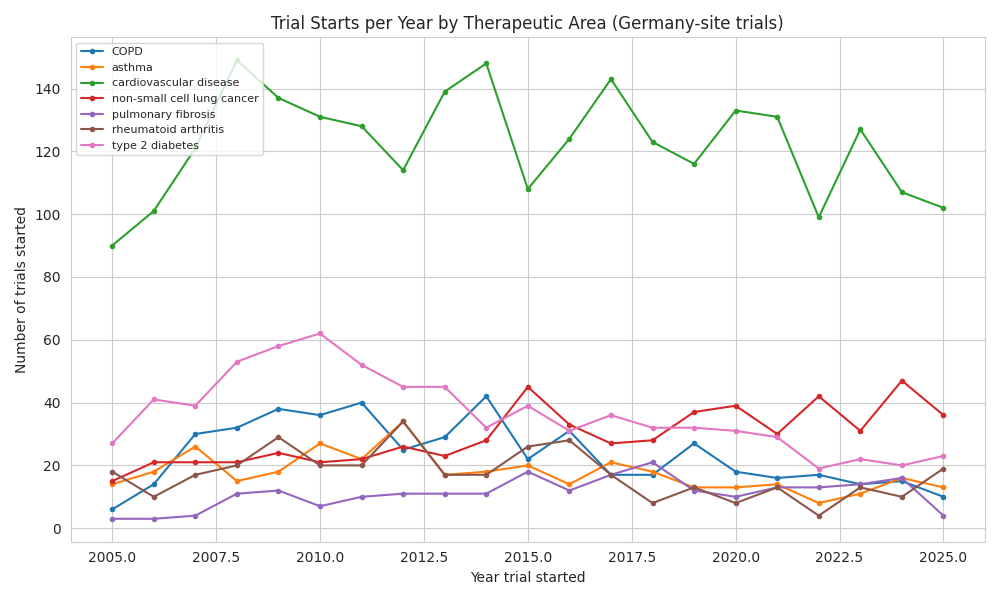

In [4]:
trials['start_year'] = pd.to_numeric(trials['start_date'].str[:4], errors='coerce')yearly = (trials[(trials['start_year']>=2005) & (trials['start_year']<=2025)]          .groupby(['start_year','search_condition']).size().reset_index(name='n'))fig, ax = plt.subplots(figsize=(10,6))for cond in yearly['search_condition'].unique():    sub = yearly[yearly['search_condition']==cond]    ax.plot(sub['start_year'], sub['n'], marker='o', markersize=3, label=cond)ax.set_xlabel('Year trial started')ax.set_ylabel('Number of trials started')ax.set_title('Trial Starts per Year by Therapeutic Area (Germany-site trials)')ax.legend(fontsize=8, loc='upper left')plt.tight_layout()plt.show()

**Takeaway:** cardiovascular disease trial starts have consistently outpaced every other areasince 2005, though with year-to-year volatility rather than a smooth trend (COVID-era years showa visible dip across all areas around 2020-2022, consistent with widely reported global trialdisruption during the pandemic — a good example of a pattern to sanity-check against knownexternal events rather than treat as a data artifact).

## 3. Trial phase by sponsor classWho's actually running trials at each phase — industry, academic, or other?

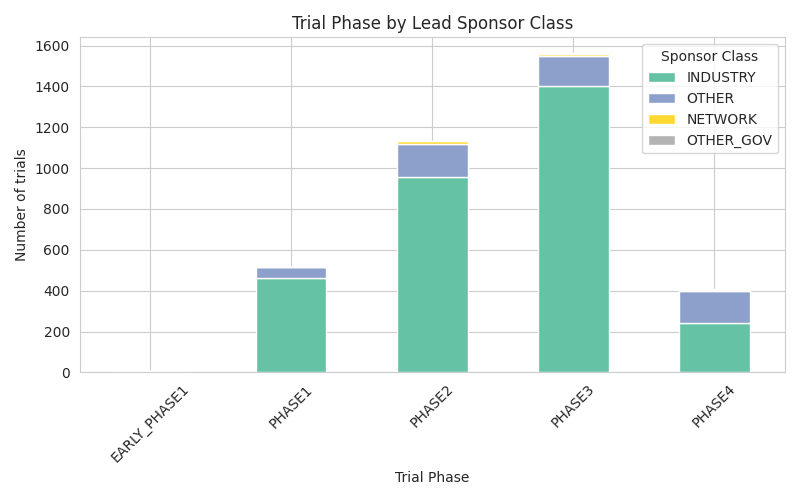

In [5]:
merged = phases.merge(trials[['nct_id','lead_sponsor_class']], on='nct_id')phase_order = ['EARLY_PHASE1','PHASE1','PHASE2','PHASE3','PHASE4']merged = merged[merged['phase'].isin(phase_order)]pivot = merged.groupby(['phase','lead_sponsor_class']).size().unstack(fill_value=0)pivot = pivot.reindex(phase_order)top_classes = merged['lead_sponsor_class'].value_counts().head(4).indexpivot = pivot[top_classes]fig, ax = plt.subplots(figsize=(8,5))pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')ax.set_xlabel('Trial Phase')ax.set_ylabel('Number of trials')ax.set_title('Trial Phase by Lead Sponsor Class')ax.legend(title='Sponsor Class')plt.xticks(rotation=45)plt.tight_layout()plt.show()

**Takeaway:** industry sponsorship dominates every phase, but especially Phase 3 — expected,since pivotal trials are expensive and typically funded by the company seeking approval, notacademic or government sponsors.

## 4. Trial status distribution

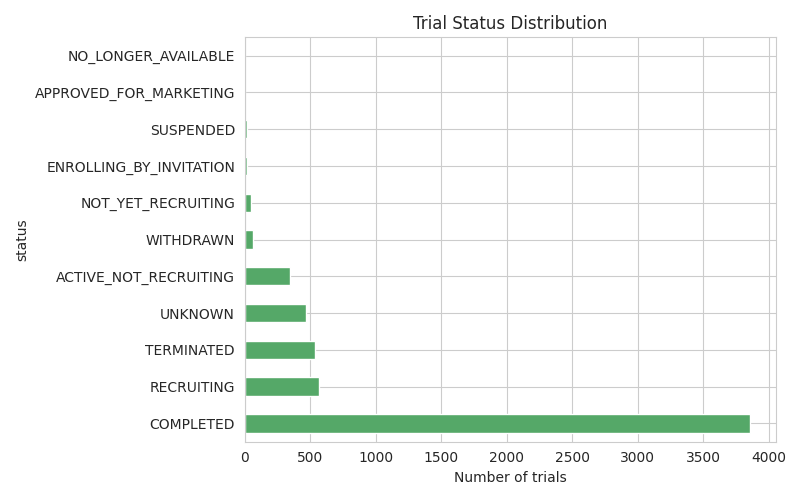

In [6]:
status_counts = trials['status'].value_counts()fig, ax = plt.subplots(figsize=(8,5))status_counts.plot(kind='barh', ax=ax, color='#55A868')ax.set_xlabel('Number of trials')ax.set_title('Trial Status Distribution')plt.tight_layout()plt.show()

## 5. Termination rate by therapeutic areaA more pointed question than raw status counts: which therapeutic areas see trials terminatedearly most often, and does that differ meaningfully by condition?

In [7]:
term_rate = (trials.groupby('search_condition')             .apply(lambda x: (x['status']=='TERMINATED').mean())             .sort_values(ascending=False))print(term_rate.round(3))

search_conditionnon-small cell lung cancer    0.148rheumatoid arthritis          0.125pulmonary fibrosis            0.113cardiovascular disease        0.086asthma                        0.078type 2 diabetes               0.063COPD                          0.060dtype: float64

**Takeaway — the most interesting finding in this notebook:** non-small cell lung cancer trialsterminate early at nearly **15%**, more than double the rate for COPD or type 2 diabetes (~6%).This is consistent with what's publicly known about oncology trials generally — they're moreexposed to early stopping for futility, safety signals, or a fast-moving competitive landscape(a competitor's drug reading out first can make a trial's original hypothesis moot). Diabetes andCOPD trials, by contrast, tend to run in more established, lower-risk therapeutic frameworks.This is exactly the kind of finding worth pulling into the dashboard as a headline metric ratherthan leaving buried in a notebook — it's a real insight, not just a chart.

## Next steps- Build the interactive dashboard (Streamlit) surfacing: therapeutic area trends, sponsor  landscape, and the termination-rate finding above as a headline insight- Add the LLM natural-language query layer on top- Note for the case study: the enrollment outlier check and the cardiovascular-disease search-term  cleanup (see `data/pull_data.py` and README) are both examples of data quality issues caught and  documented rather than ignored — worth naming explicitly when presenting this project.